In [4]:
import pickle
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from collections import Counter
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)
from typing import Optional

from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples




In [5]:
def plot_several_p_dist(
    axs: list[Axes], 
    filename, prob,
    db_fixed, dg_fixed, shots,
    ps, rescale,
    max_beta_T:Optional[float]=None, eps:Optional[float]=None, alpha:Optional[float]=None, 
    simulation:Optional[bool]=None, error_mitigation:Optional[bool]=None,
    backend:Optional[str]=None,
    iters=None, normalise=False
) -> list[Axes]:
    data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

    _, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
    num_qubits: int = hamiltonian.num_qubits

    base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
    append_str = (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'{".simulation" if simulation else ""}') + (f'.db{db_fixed}.dg{dg_fixed}.shots{shots}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
    with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    sample_sequence = []
    samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    keys = samples_dict.keys()
    energies = res['energies']
    if iters is None:
        iters = [0, 5, 9]
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    cutoff = 25
    ax = axs[0]
    rand_shots = min(shots*10, 40000)
    random_samples = np.random.choice(('0', '1'), (rand_shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(ising_offset + evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/rand_shots]*len(rand_vals), rwidth=1, log=True, color='gray', label='Random')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)
    

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    
    for i in range(1, len(axs)):
        ax = axs[i]
        sample_sequence = []
        for p in ps:
            rescale_value = None
            for key in keys:
                if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                    rescale_value = key[1]
                    break
            if rescale_value is None:
                raise Exception('Could not rescale value')
            if len(samples_dict[(p, rescale_value)]) > 3:
                counter = Counter(samples_dict[(p, rescale_value)][iters[i-1]])
            else:
                counter = Counter(samples_dict[(p, rescale_value)][i-1])
            if i == len(axs) - 1:
                print(p, counter.most_common(2))
            evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
            
            # energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
            energies = [count * [evals[idx]] for idx, count in enumerate(counter.values())]
            sample_vals = np.array([x for xs in energies for x in xs])
            # if alpha is not None:
            #     sample_vals = np.sort(sample_vals)[:int(alpha * len(sample_vals))]
            sample_sequence.append(sample_vals)

        ax.hist(sample_sequence, bins=range(cutoff+1), weights=[[1/len(sample_vals)]*len(sample_vals) for sample_vals in sample_sequence], rwidth=1, log=True, label=ps)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]+1}', ha='right', va='top', transform=ax.transAxes)
          
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    return axs




1 [('00101000', 1224), ('00101001', 223)]
3 [('00101000', 678), ('00101100', 134)]
5 [('01000001', 193), ('00100001', 82)]


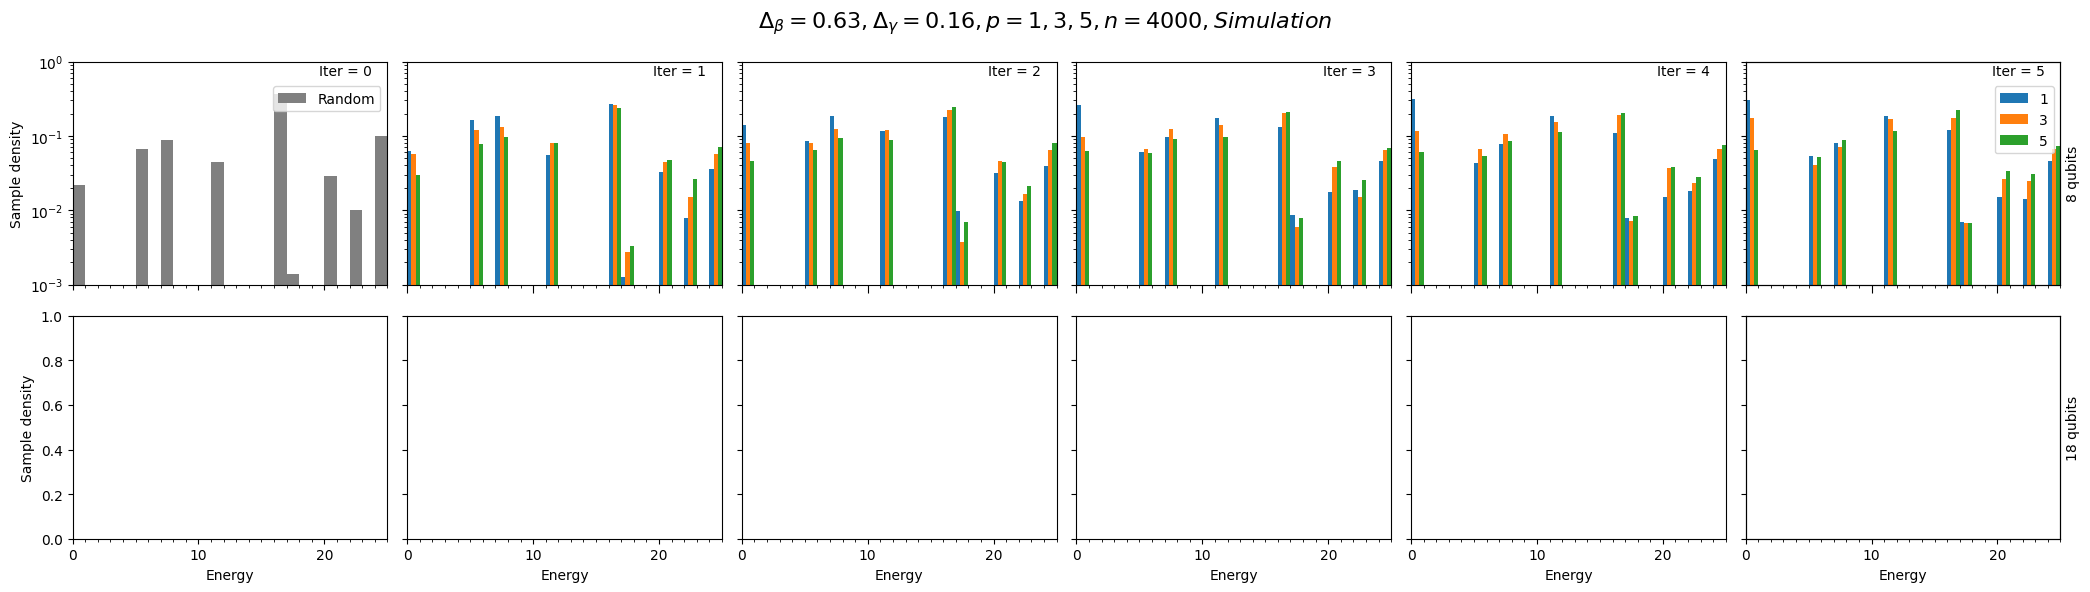

In [3]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 4000
ps = [1,3,5]
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
# axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, simulation=True)

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000, Simulation$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

1 [('00101000', 3499), ('00101100', 1072)]
3 [('00000001', 274), ('01000001', 271)]
1 [('000010001000100000', 140), ('000010001000000001', 90)]
3 [('010000000000001000', 8), ('000000000100000001', 7)]


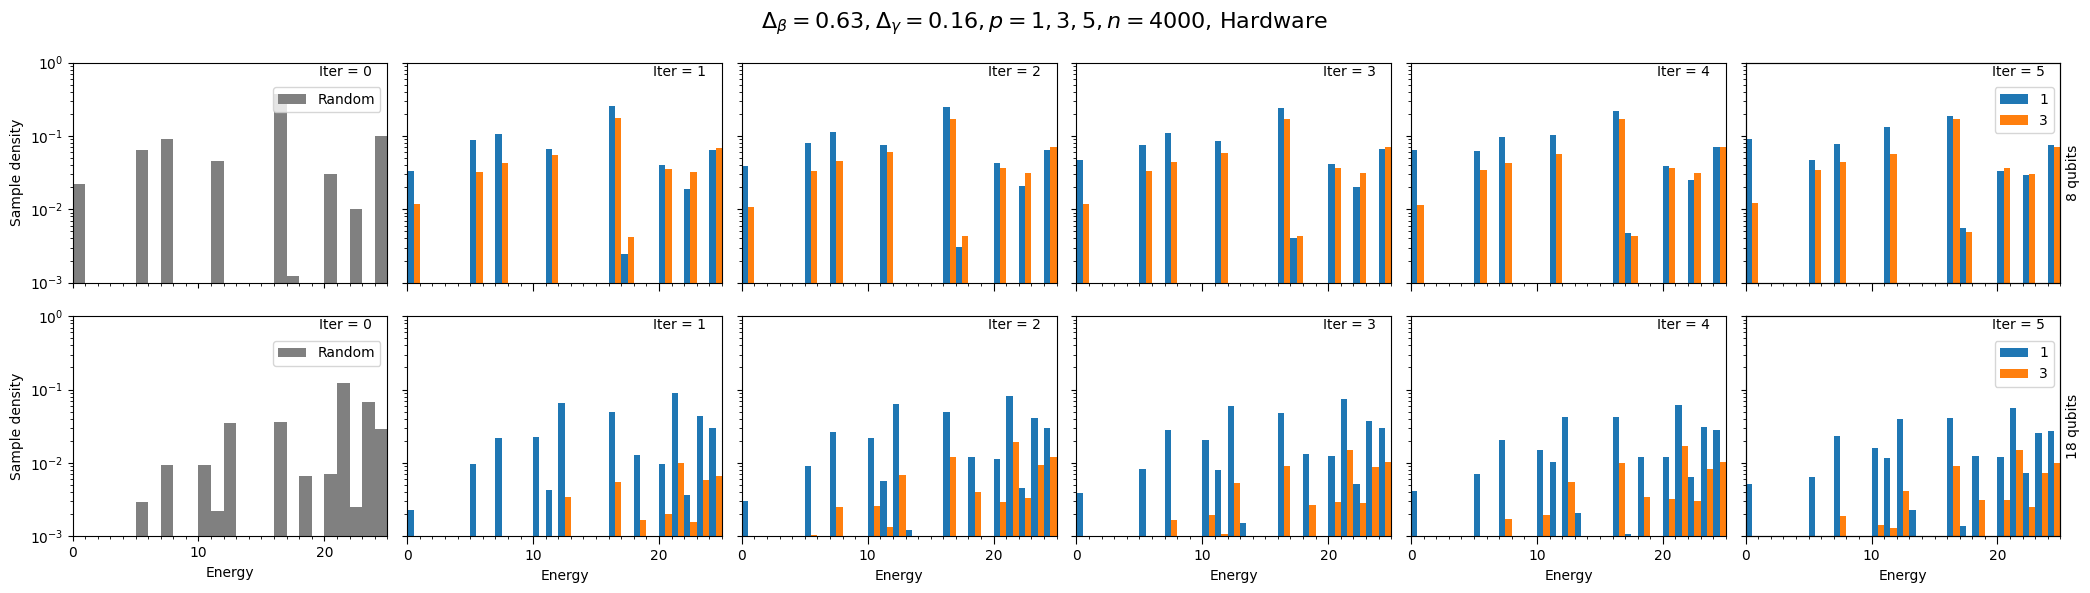

In [4]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
ps = [1,3]
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
plot_several_p_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$, Hardware', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

1 [('000010001000100000', 999), ('000010000000100000', 264)]
3 [('000010001000100000', 75), ('000010001000000000', 25)]


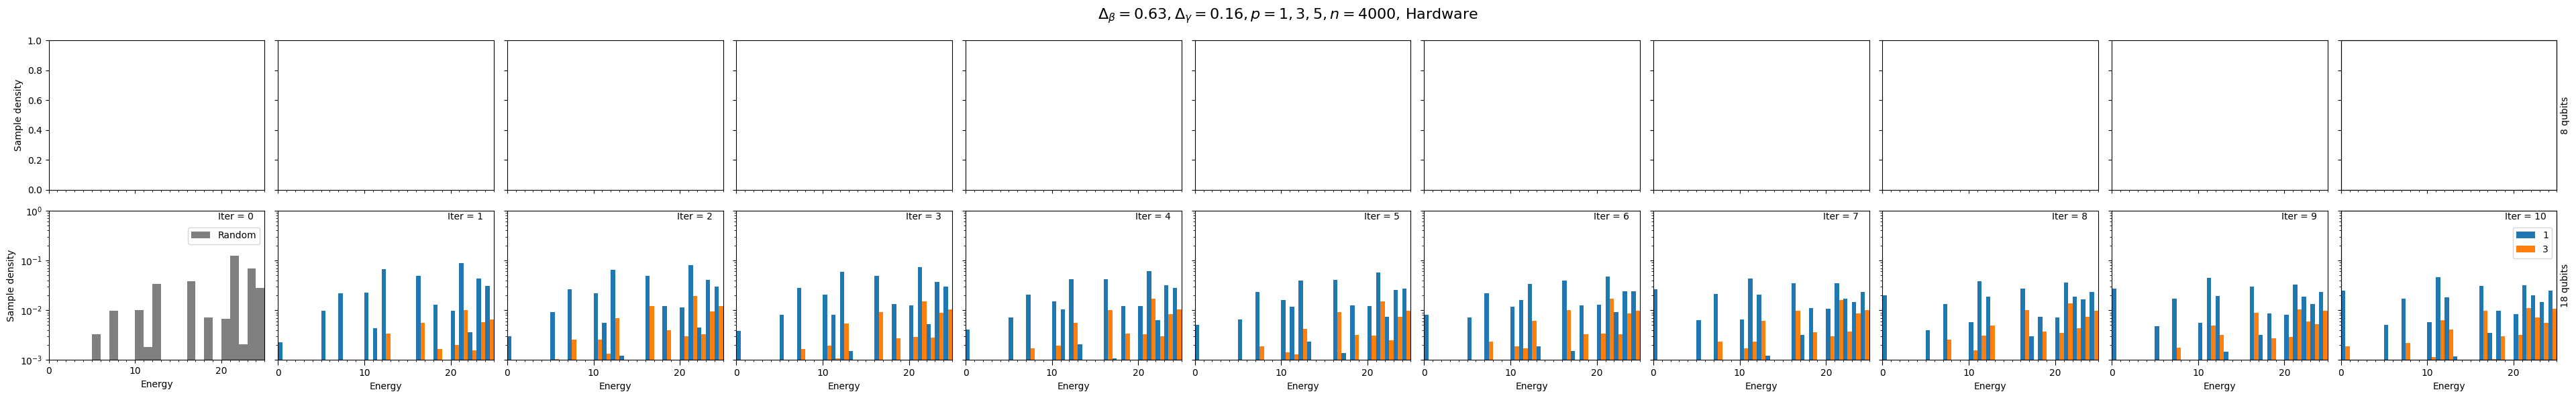

In [5]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
ps = [1,3]
iters=range(10)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

# plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
plot_several_p_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$, Hardware', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [19]:
def compare_hardware_and_noiseless(
    axs: list[Axes], 
    filename, prob,
    db_fixed, dg_fixed, shots,
    p, rescale,
    max_beta_T:Optional[float]=None, eps:Optional[float]=None, alpha:Optional[float]=None, 
    error_mitigation:Optional[bool]=None, backend:Optional[str]=None,
    iters=None
) -> list[Axes]:
    data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

    _, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
    num_qubits: int = hamiltonian.num_qubits

    base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
    append_str = (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'.db{db_fixed}.dg{dg_fixed}.shots{shots}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
    with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
        res = pickle.load(f)

    base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{int(shots*alpha)}'
    append_str = (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha1.0' if alpha is not None else '')
    with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
        simulation_res = pickle.load(f)
        
    sample_sequence = []

    # samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    # simulation_samples_dict: dict[tuple[int, float], list[list[str]]] = simulation_res['samples_dict']
    samples_dicts = {
        'hardware': res['samples_dict'],
        'simulation': simulation_res['samples_dict']
    }

    if iters is None:
        iters = [0, 5, 9]
    
    cutoff = 25
    ax = axs[0]
    rand_shots = min(shots*10, 40000)
    random_samples = np.random.choice(('0', '1'), (rand_shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(ising_offset + evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/rand_shots]*len(rand_vals), rwidth=1, log=True, color='gray', label='Random')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(1/shots, 10**0)
    

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    
    for i in range(1, len(axs)):
        ax = axs[i]
        sample_sequence = []
        for name in samples_dicts.keys():
            rescale_value = None
            for key in samples_dicts[name].keys():
                if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                    rescale_value = key[1]
                    break
            if rescale_value is None:
                raise Exception('Could not rescale value')
            try:
                if len(samples_dicts[name][(p, rescale_value)]) > 3:
                    counter = Counter(samples_dicts[name][(p, rescale_value)][iters[i-1]])
                else:
                    counter = Counter(samples_dicts[name][(p, rescale_value)][i-1])
                if i == len(axs) - 1:
                    print(p, counter.most_common(2))
                evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
                
                energies = [count * [evals[idx]] for idx, count in enumerate(counter.values())]
                sample_vals = np.array([x for xs in energies for x in xs])
                sample_sequence.append(sample_vals)
                if alpha is not None and name == 'hardware':
                    quasi_sample_vals = np.sort(sample_vals)[:int(alpha * len(sample_vals))]
                    sample_sequence.append(quasi_sample_vals)
            except:
                pass
            

        ax.hist(
            sample_sequence, 
            bins=range(cutoff+1), 
            weights=[[1/len(sample_vals)]*len(sample_vals) for sample_vals in sample_sequence], 
            rwidth=1, 
            log=True, 
            label=['Hardware', 'Simulation'] if alpha is None else ['Hardware', 'E-M Hardware', 'Simulation']
        )
        ax.set_xlim(0, cutoff)
        ax.set_ylim(1/shots, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]+1}', ha='right', va='top', transform=ax.transAxes)
          
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    return axs




1 [('00101000', 3499), ('00101100', 1072)]
1 [('01000001', 847), ('01001000', 360)]
1 [('000010001000100000', 140), ('000010001000000001', 90)]
1 [('000010001000100000', 410), ('010000001000100000', 79)]
1 [('000001100000000100000001', 12), ('000001100000000000000001', 8)]
1 [('000010001000010000000001', 10), ('000010001000000010001000', 9)]
1 [('0100000000000000000000000001', 10), ('0100000000010000000000000001', 5)]
1 [('0100000000000000000000000001', 368), ('0000000000000000000000000001', 37)]
1 [('0111010001010100000001110010111000011000', 1), ('0100101101000000100100101010001010100000', 1)]
1 [('0000100000010000000000100000100000010000', 50), ('0000100000010000000000100000100000000001', 25)]


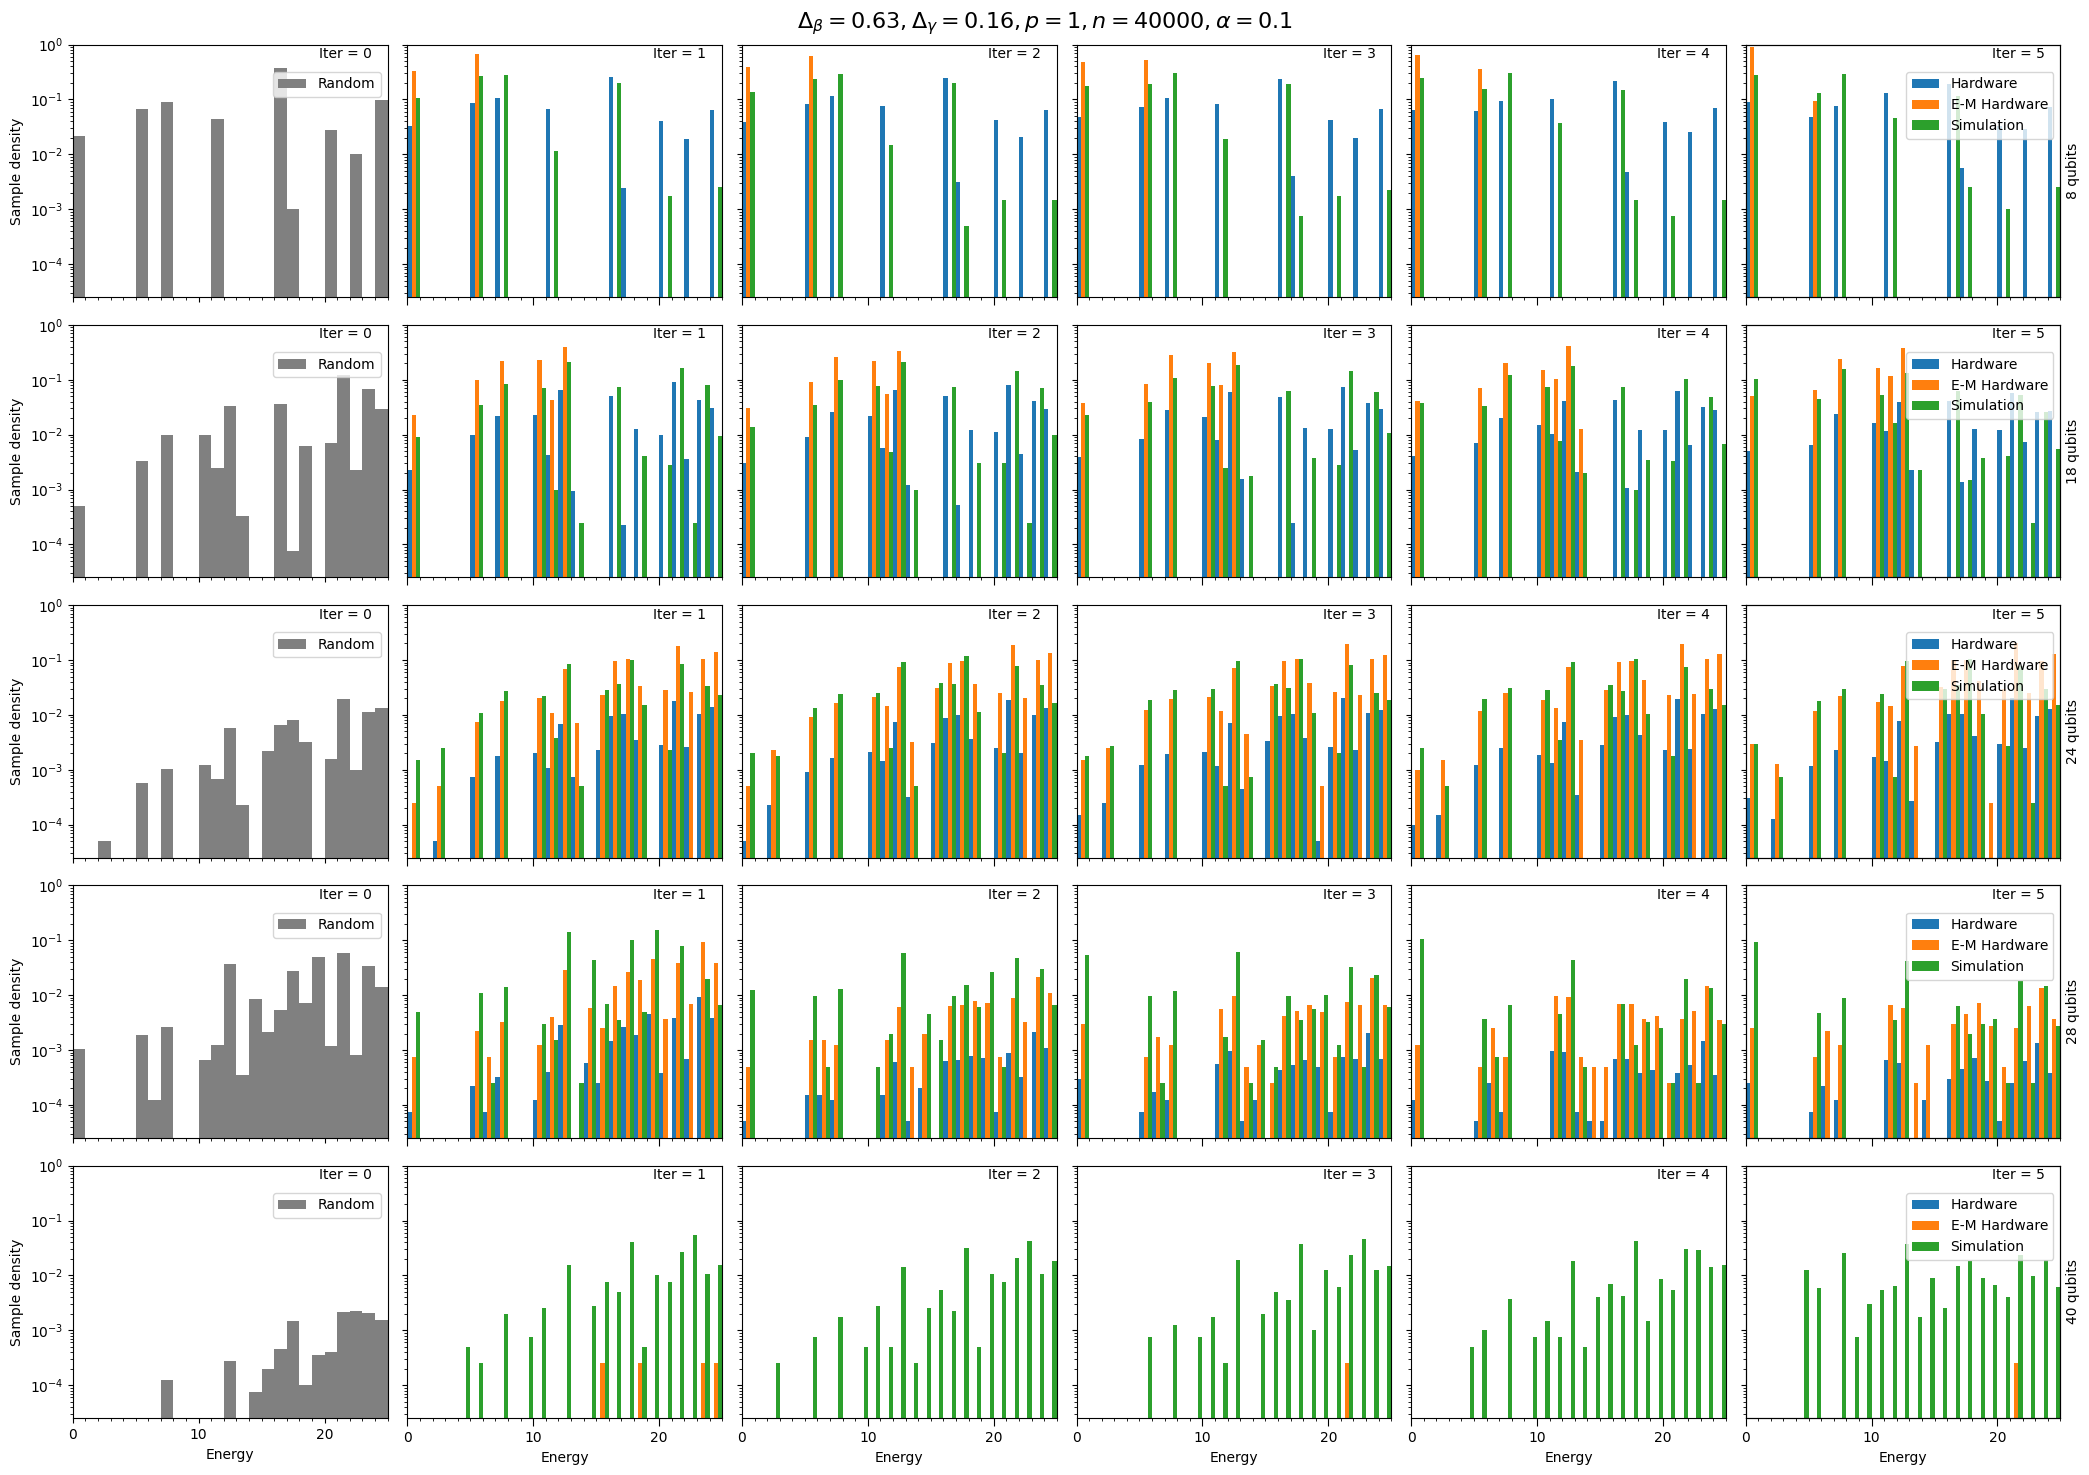

In [53]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(5, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]

compare_hardware_and_noiseless(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
compare_hardware_and_noiseless(axs1, 'trivial',    (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs3, 'test_N7_W2', (2*7)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs4, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18,24, 28, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

1 [('000010001000100000', 1101), ('000010000000100000', 322)]
1 [('000001100000000100000001', 175), ('000001100000000101000001', 39)]
1 [('0100000000000000000000000001', 9), ('0110000000000000000000000001', 7)]
1 [('0101111000000010000100000010101101110111', 1), ('0110001001010110101011100011000001101010', 1)]


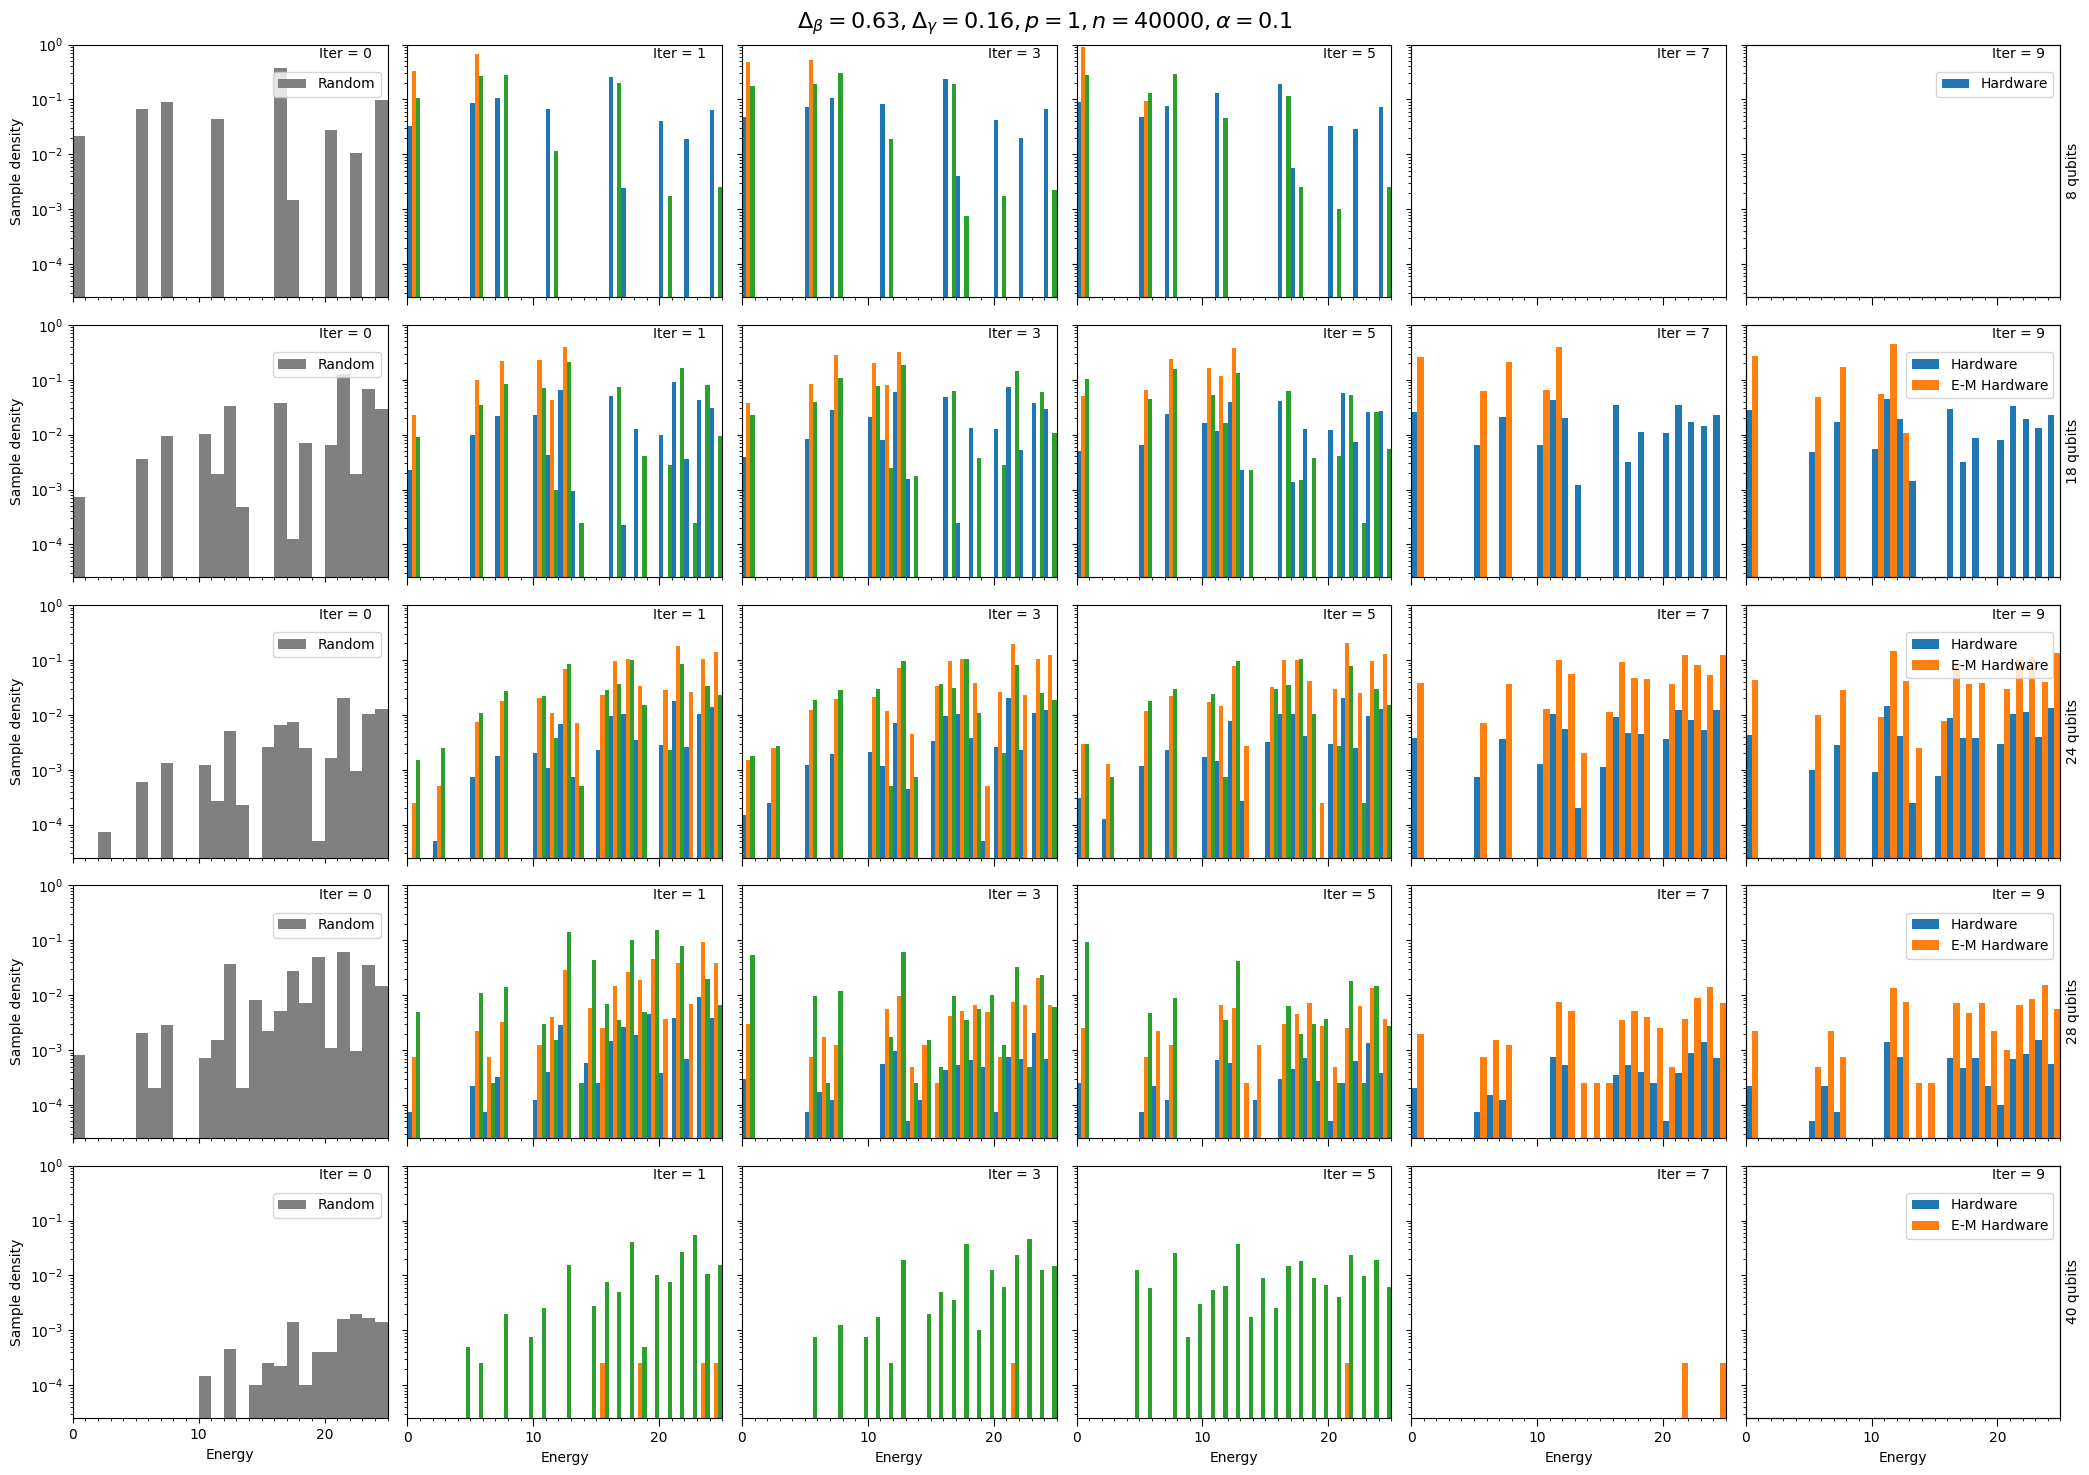

In [118]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
iters=range(0,10,2)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(5, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]

compare_hardware_and_noiseless(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
compare_hardware_and_noiseless(axs1, 'trivial',    (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs3, 'test_N7_W2', (2*7)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs4, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18,24, 28, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [114]:
filename='trivial'
error_mitigation=True
backend='ibm_boston'
# backend = None
simulation=False
n=40000
alpha=0.1
delta_b_fixed=0.63
delta_g_fixed=0.16

data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
append_str = (".simulation" if simulation else "")+ (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'.db{delta_b_fixed}.dg{delta_g_fixed}.shots{n}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    res = pickle.load(f)
samples = res['samples_dict'][(1,1)]
{i : {k: v/n for k,v in Counter([x.count('1') for x in samples[-1]]).items()}.get(i, 0) for i in range(num_qubits+1)}




{0: 7.5e-05,
 1: 0.00275,
 2: 0.0272,
 3: 0.10695,
 4: 0.154775,
 5: 0.17,
 6: 0.16265,
 7: 0.136325,
 8: 0.10045,
 9: 0.06395,
 10: 0.040875,
 11: 0.019975,
 12: 0.01,
 13: 0.002875,
 14: 0.000975,
 15: 0.000175,
 16: 0,
 17: 0,
 18: 0}

In [116]:
samples_counter = Counter(samples[-1])
evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(samples_counter.keys()), hamiltonian), 2)

sample_energies = []
sample_vals = []
for idx, (sample, count) in enumerate(samples_counter.items()):
    sample_energies.extend(count * [evals[idx]])
    sample_vals.extend(count * [sample])
sample_energies = np.array(sample_energies)
sample_vals = np.array(sample_vals)
idx = np.argsort(sample_energies)
quasi_energies = sample_energies[idx][:int(alpha * len(sample_vals))]

quasi_samples = sample_vals[idx][:int(alpha * len(sample_vals))]
{i : {k: v/(n*alpha) for k,v in Counter([x.count('1') for x in quasi_samples]).items()}.get(i, 0) for i in range(num_qubits+1)}

{0: 0,
 1: 0,
 2: 0,
 3: 0.5375,
 4: 0.4625,
 5: 0,
 6: 0,
 7: 0,
 8: 0,
 9: 0,
 10: 0,
 11: 0,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0}

In [105]:
filename='trivial'
delta_b_fixed=1.0
delta_g_fixed=0.06

n=4000
alpha=1.0
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{delta_b_fixed}.dg{delta_g_fixed}.shots{int(n)}'
append_str = (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha1.0' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    simulation_res = pickle.load(f)
samples = simulation_res['samples_dict'][(1,1)]
{i : {k: v/n for k,v in Counter([x.count('1') for x in samples[-1]]).items()}.get(i,0) for i in range(num_qubits+1)}

{0: 0.001,
 1: 0.01225,
 2: 0.11475,
 3: 0.43075,
 4: 0.26825,
 5: 0.12675,
 6: 0.03525,
 7: 0.00975,
 8: 0.00125,
 9: 0,
 10: 0,
 11: 0,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0}

In [99]:
from scipy.stats import binom
B = binom(num_qubits, 1/(2*3))
{i: B.pmf(i) for i in range(num_qubits+1)}

{0: np.float64(0.012579115212475327),
 1: np.float64(0.06037975301988153),
 2: np.float64(0.1388734319457275),
 3: np.float64(0.20368103352040048),
 4: np.float64(0.21386508519642045),
 5: np.float64(0.17109206815713626),
 6: np.float64(0.10835830983285304),
 7: np.float64(0.05572713077118153),
 8: np.float64(0.023684030577752133),
 9: np.float64(0.008420988649867445),
 10: np.float64(0.002526296594960229),
 11: np.float64(0.0006430573150807857),
 12: np.float64(0.00013932908493417007),
 13: np.float64(2.5722292603231377e-05),
 14: np.float64(4.042074551936374e-06),
 15: np.float64(5.389432735915152e-07),
 16: np.float64(6.063111827904549e-08),
 17: np.float64(5.706458190968991e-09),
 18: np.float64(4.4383563707536574e-10),
 19: np.float64(2.8031724446865196e-11),
 20: np.float64(1.4015862223432592e-12),
 21: np.float64(5.339376085117174e-14),
 22: np.float64(1.4561934777592312e-15),
 23: np.float64(2.5325103961030104e-17),
 24: np.float64(2.1104253300858407e-19)}

In [54]:
filename='test_N4_W5'
error_mitigation=True
backend='ibm_boston'
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
append_str = (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'.db{delta_b_fixed}.dg{delta_g_fixed}.shots{n}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    res = pickle.load(f)

In [55]:
samples = res['samples_dict'][(1,1)]

In [56]:
base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{delta_b_fixed}.dg{delta_g_fixed}.shots{int(n*alpha)}'
append_str = (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha1.0' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    simulation_res = pickle.load(f)

In [57]:
sim_samples = simulation_res['samples_dict'][(1,1)]

1 [('000010001000100000', 1101), ('000010000000100000', 322)]
1 [('010000000100000001', 3736), ('010001000100000001', 459)]


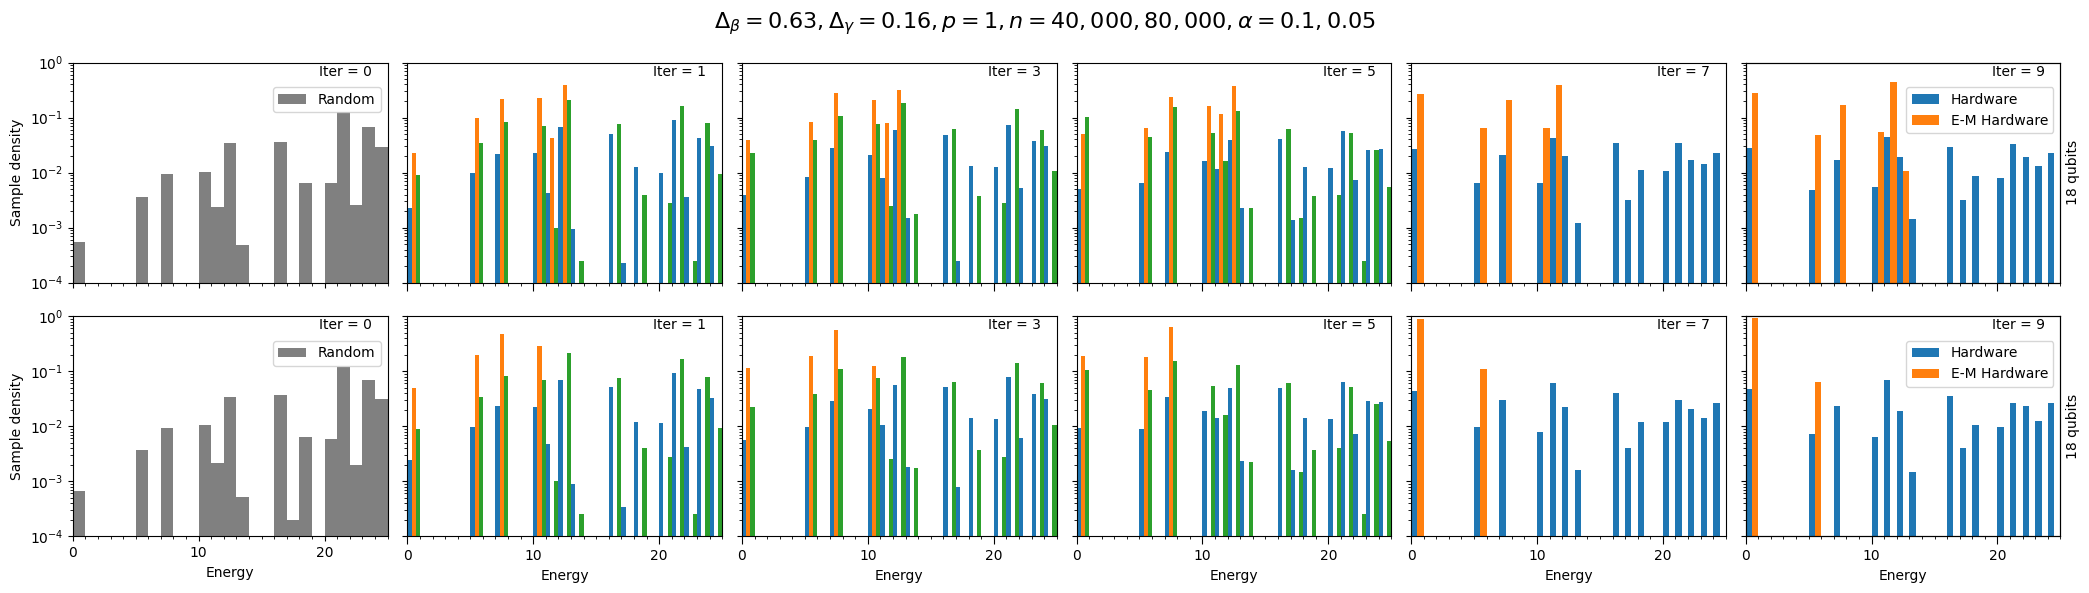

In [13]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

iters=range(0,10,2)
max_beta_T = 0.15
eps = 0.15
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

compare_hardware_and_noiseless(axs0, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 40000, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=0.1, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 80000, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=0.05, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [18,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = 40,000, 80,000, \\alpha = 0.1,0.05$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

3 [('00000001', 274), ('01000001', 271)]
3 [('01000001', 3423), ('10000001', 94)]
3 [('010000000000001000', 8), ('000000000100000001', 7)]
3 [('010000000100000001', 2739), ('010000000100000000', 105)]
3 [('000001001000100001010101', 3), ('001001101100001001101000', 2)]
3 [('010000000010001000000001', 1315), ('010000000010001000010000', 493)]


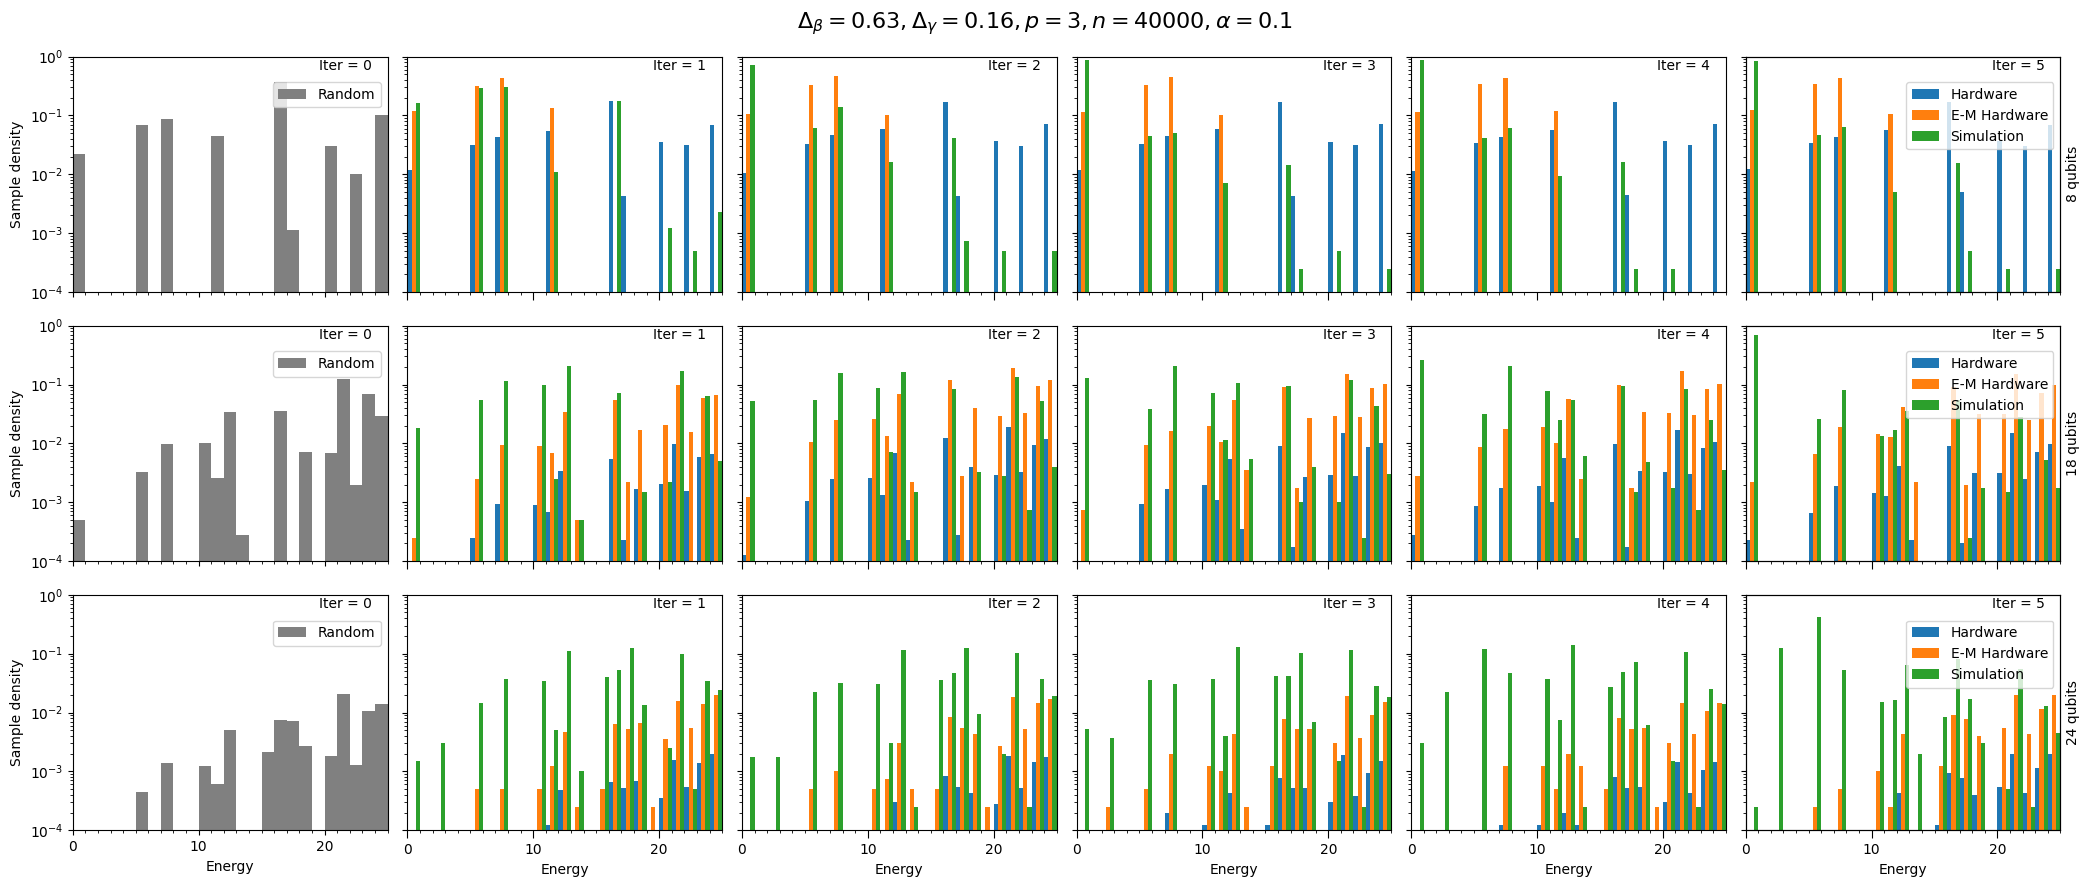

In [ ]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
p = 3
# ENERGIES ** 2

fig, axs = plt.subplots(4, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
# axs4 = axs[4, :]

compare_hardware_and_noiseless(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
compare_hardware_and_noiseless(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs3, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")



for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18, 24]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [2]:
2**18

262144

In [ ]:
from qubo_qaoa.utils.lr_qaoa import get_hardware_LR_qaoa_circuit


In [ ]:

from qopt_best_practices.sat_mapping import SATMapper
from qiskit_ibm_runtime import QiskitRuntimeService
import networkx as nx
from itertools import combinations
from qiskit.circuit.library import QAOAAnsatz
from qiskit_qaoa.utils.circuit_graph_utils import circuit_to_graph, graph_to_operator
from qiskit.circuit import ParameterVector

from qubo_qaoa.utils.swap_strategy import QUBOSwapStrategy

In [ ]:
filename = 'trivial'
p = 1
num_qubits = 18


service = QiskitRuntimeService(name='eu_test_instance')
backend = service.least_busy(min_num_qubits=num_qubits, operational=True, simulator=False) 


data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
Q, hamiltonian, offset, ising_offset = get_Q_and_hamiltonian(data_file)
rows, cols = 1, 1
while 4 * (rows + cols + rows * cols) < num_qubits:
    if rows < cols:
        rows += 1
    else:
        cols += 1
print(f'Min size to support virtual qubits: {(rows, cols)}')

swap_strat = QUBOSwapStrategy.from_heavy_hex(rows, cols)
coupling_map = swap_strat._coupling_map
coupling_map_edge = list(coupling_map)
physical_qubits = list(coupling_map.physical_qubits)

dual_coupling_map = nx.Graph()

for qubit in physical_qubits:
    edges = [edge for edge in coupling_map_edge if edge[0]==qubit]
    for edge1, edge2 in combinations(edges, 2):
        dual_coupling_map.add_edge(tuple(sorted(edge1)), tuple(sorted(edge2)))
edge_colouring = nx.greedy_color(dual_coupling_map, interchange=True)
edge_colouring_copy = {}
for k, v in edge_colouring.items():
    edge_colouring_copy[k] = v
    edge_colouring_copy[k[::-1]] = v

qc = QAOAAnsatz(
    cost_operator=hamiltonian,
    reps = 1,
    flatten=True
)
graph = circuit_to_graph(qc, qc.parameters[1])

remapped_g, sat_map, min_sat_layers = SATMapper(timeout=30).remap_graph_with_sat(
    graph=graph, swap_strategy=swap_strat, max_layers = int(num_qubits + np.sqrt(num_qubits) + 61)
)
if remapped_g is None or sat_map is None:
    raise Exception('Failed to find initial layout')

cost_op = graph_to_operator(remapped_g, swap_strat._num_vertices)

phis = ParameterVector('ϕ', num_qubits)
fixed_qc, circ = get_hardware_LR_qaoa_circuit(
    p, delta_b_fixed, delta_g_fixed, num_qubits,
    cost_op, sat_map, backend, edge_colouring_copy, swap_strat,
    None, phis=phis,
)

Min size to support virtual qubits: (1, 2)


In [ ]:
def print_circuit_info(qc, circuit_name):
    print(f'{circuit_name} has {qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0) + qc.count_ops().get("ecr", 0)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')
    print(qc.count_ops())

In [ ]:
fixed_qc.count_ops()

OrderedDict([('rz', 1767),
             ('sx', 910),
             ('ecr', 504),
             ('x', 113),
             ('measure', 18)])

In [ ]:
print_circuit_info(fixed_qc, 'fixed qc')

fixed qc has 504 2Q gates     and 164 2Q depth
OrderedDict([('rz', 1767), ('sx', 910), ('ecr', 504), ('x', 113), ('measure', 18)])


In [ ]:
fixed_qc.draw(fold=-1)

global phase: π
                    ┌────┐  ┌───────────────┐  ┌────┐  ┌───────────┐    ┌────┐   ┌────────┐    ┌──────┐   ┌──────────┐  ┌────────┐     ┌────┐      ┌────────┐    ┌──────┐     ┌────┐                                                ┌──────┐ ┌──────────┐     ┌────┐      ┌────────┐              ┌──────┐ ┌─────────┐  ┌────┐ ┌─────────┐               ┌──────┐  ┌────────┐    ┌────┐    ┌─────────┐    ┌──────┐    ┌─────────┐      ┌────┐                     ┌──────┐    ┌──────────┐                              ┌──────┐  ┌────────┐                                                                                                  ┌──────┐  ┌─────────┐ ┌────────┐    ┌────┐   ┌────────┐ ┌──────┐   ┌────┐   ┌─────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         ┌──────┐ ┌──────────┐    ┌────┐      ┌────────┐    ┌──────┐  ┌─────────┐    ┌────┐  ┌─────────┐   ┌──────┐   ┌──────────┐     ┌────┐    ┌──────────┐  ┌──────┐    ┌────┐                                                ┌──────┐  ┌──────────┐   ┌────┐                 ┌──────┐     ┌───┐    ┌──────────┐                                    ┌──────┐┌─────────┐    ┌────┐   ┌─────────┐   ┌──────┐  ┌─────────┐   ┌────┐               ┌──────┐  ┌──────────┐                        ┌──────┐     ┌───┐    ┌──────────┐              ┌──────┐    ┌──────────┐     ┌────┐     ┌────────┐                  ┌──────┐ ┌─────────┐      ┌────┐    ┌─────────┐               ┌──────┐   ┌────┐      ┌────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           ┌──────┐     ┌───┐   ┌──────────┐                    ┌──────┐ ┌────────┐  ┌──

In [ ]:
service = QiskitRuntimeService(name='eu_test_instance')
backend = service.least_busy(min_num_qubits=num_qubits, operational=True, simulator=False) 
# QRYmgEXFuqjyzrJvAGQiJQoyZD2tcSHTxpckcpc50Psj

In [ ]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="QRYmgEXFuqjyzrJvAGQiJQoyZD2tcSHTxpckcpc50Psj",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/cab32497708745b09a68cbfdf5f415aa:d4e63032-8000-4920-a6ed-26af87813cbe::"
)

In [ ]:
QiskitRuntimeService.save_account(
  token="QRYmgEXFuqjyzrJvAGQiJQoyZD2tcSHTxpckcpc50Psj",
  name="us_instance", # Optional
  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/cab32497708745b09a68cbfdf5f415aa:d4e63032-8000-4920-a6ed-26af87813cbe::", # Optional
  set_as_default=False, # Optional
  overwrite=True, # Optional
)

In [ ]:
service.saved_accounts()

{'Josh Cudby': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'QRYmgEXFuqjyzrJvAGQiJQoyZD2tcSHTxpckcpc50Psj',
  'instance': 'crn:v1:bluemix:public:quantum-computing:eu-de:a/cab32497708745b09a68cbfdf5f415aa:70e78df2-eefe-41d3-b8ee-36b631ca4dda',
  'verify': True,
  'private_endpoint': False},
 'default-ibm-quantum-platform': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'QRYmgEXFuqjyzrJvAGQiJQoyZD2tcSHTxpckcpc50Psj',
  'verify': True,
  'private_endpoint': False},
 'eu_test_instance': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'QRYmgEXFuqjyzrJvAGQiJQoyZD2tcSHTxpckcpc50Psj',
  'instance': 'crn:v1:bluemix:public:quantum-computing:eu-de:a/cab32497708745b09a68cbfdf5f415aa:70e78df2-eefe-41d3-b8ee-36b631ca4dda::',
  'verify': True,
  'private_endpoint': False,
  'region': 'eu-de'},
 'us_instance': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'QRYmgEXFu

In [ ]:
service = QiskitRuntimeService(name='us_instance')


In [ ]:
service.backends()

[<IBMBackend('ibm_pittsburgh')>,
 <IBMBackend('ibm_boston')>,
 <IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_torino')>,
 <IBMBackend('ibm_miami')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]